In [97]:
# Import required python packages

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import panel as pn

In [99]:
# Load World Bank Commodity Price Data (The Pink Sheet)

df = pd.read_excel("/Users/williamcolville/Desktop/Apprenticeship/Data Science Professional Practice/Assessment WIP/CMO-Historical-Data-Monthly-May.xlsx", sheet_name = "Monthly Prices", header = 4)[1:]
# df = pd.read_excel("/Users/williamcolville/Downloads/CMO-Historical-Data-Monthly.xlsx", sheet_name = "Monthly Prices", header = 4)[1:]

In [101]:
# Convert date column into datetime type

df = df.rename(columns = {"Unnamed: 0" : "date"})
df.columns = [x.lower().strip() for x in df.columns]
df["date"] = pd.to_datetime(df["date"], format="%YM%m")

# Handling any non-numeric commodity values ("...") and dropping provided aggregated columns

df[df.columns.difference(["date"])] = df[df.columns.difference(["date"])].apply(pd.to_numeric, errors="coerce")
df = df.sort_values(by = "date", ascending = True).drop(columns = ["crude oil, average", "natural gas index", "cotton, a index", "tea, avg 3 auctions"]).reset_index(drop = True)

In [103]:
# Understanding data gaps

(df[df["date"] >= "1990-01-01"].isna().mean() * 100).sort_values(ascending = False).head(15)

# phosphate rock - One missing value, a big drop in price and constant since gap - might be best to model pre-drop up to Oct 2023
# tobacco, us import u.v. - Latest two values are missing
# rice, thai 25% - One cell gap (small shift in price), 4 cell gap (big shift in price), perhaps best to model chains either side of gap - Up to Jan 2008 and from Jul 2008
# wheat, us srw - One cell and six cell gaps - no big shift in prices either side of gaps
# shrimps, mexican - No data since Nov 2023 - Model up to this point
# sawnwood, cameroon - Constant price in 1990 followed by a gap to Jan 1995. Model from 1995.
# barley - No data from Aug 2020. Model up to this point.
# sorghum - No data from Aug 2020. Model up to this point.
# palm kernel oil - Data from Jan 1996
# banana, europe - Data from Jan 1997
# rubber, tsr20 ** - Data from Jan 1999
# rapeseed oil - Data from Feb 2002
# sunflower oil - Data from Feb 2002 - Two small gaps, 1 and 3 cells with no big shifts in price
# rice, viet namese 5% - Data from Dec 2003 to Nov 2007 with two small gaps then 5 month gap and big shift - likely best to model this Jun 2008 onwards

rice, viet namese 5%       40.825688
sunflower oil              34.403670
rapeseed oil               33.256881
rubber, tsr20 **           24.770642
banana, europe             19.266055
palm kernel oil            16.513761
sorghum                    15.596330
barley                     15.596330
sawnwood, cameroon         11.009174
shrimps, mexican            6.880734
wheat, us srw               1.605505
rice, thai 25%              1.376147
tobacco, us import u.v.     0.458716
phosphate rock              0.229358
sugar, world                0.000000
dtype: float64

In [105]:
# Dropping columns with substantial missingness or are not suitable for interpolation/extrapolation

df = df.drop(columns = [
    "phosphate rock"
    , "rice, thai 25%"
    , "shrimps, mexican"
    , "sawnwood, cameroon"
    , "barley", "sorghum"
    , "palm kernel oil"
    , "banana, europe"
    , "rubber, tsr20 **"
    , "rapeseed oil"
    , "sunflower oil"
    , "rice, viet namese 5%"])

# Interpolating/extrapolating data gaps

df["tobacco, us import u.v."] = df["tobacco, us import u.v."].interpolate(method = "linear", axis = 0, limit = 3, limit_direction = "forward", limit_area = "outside")
df["wheat, us srw"] = df["wheat, us srw"].interpolate(method = "linear", axis = 0, limit = 6, limit_direction = "forward")

(df[df["date"] >= "1990-01-01"].isna().mean() * 100).sort_values(ascending = False).head(15)

date                       0.0
crude oil, brent           0.0
beef **                    0.0
chicken **                 0.0
lamb **                    0.0
sugar, eu                  0.0
sugar, us                  0.0
sugar, world               0.0
tobacco, us import u.v.    0.0
logs, cameroon             0.0
logs, malaysian            0.0
sawnwood, malaysian        0.0
plywood                    0.0
rubber, rss3               0.0
dap                        0.0
dtype: float64

In [107]:
# Commodities

commodities = list(df.columns.difference(["date"]))

In [255]:
# Price from 1990 baseline

change = {"date" : df[df["date"] >= "1990-01-01"]["date"].reset_index(drop = True).copy()}
change_cols = []
prices_df = df[df["date"] >= "1990-01-01"].reset_index(drop = True).copy()

for commodity in commodities:
    series = pd.Series(prices_df[commodity] / prices_df[commodity][0], name = f"{commodity}")
    change[f"{commodity}"] = series
    change_cols.append(f"{commodity}")

change_df = pd.concat(change.values(), axis = 1).set_index("date", drop=True).T
max_multiplier = np.round(np.max(change_df[[x for x in change_df.columns if x != "date"]]), 0)

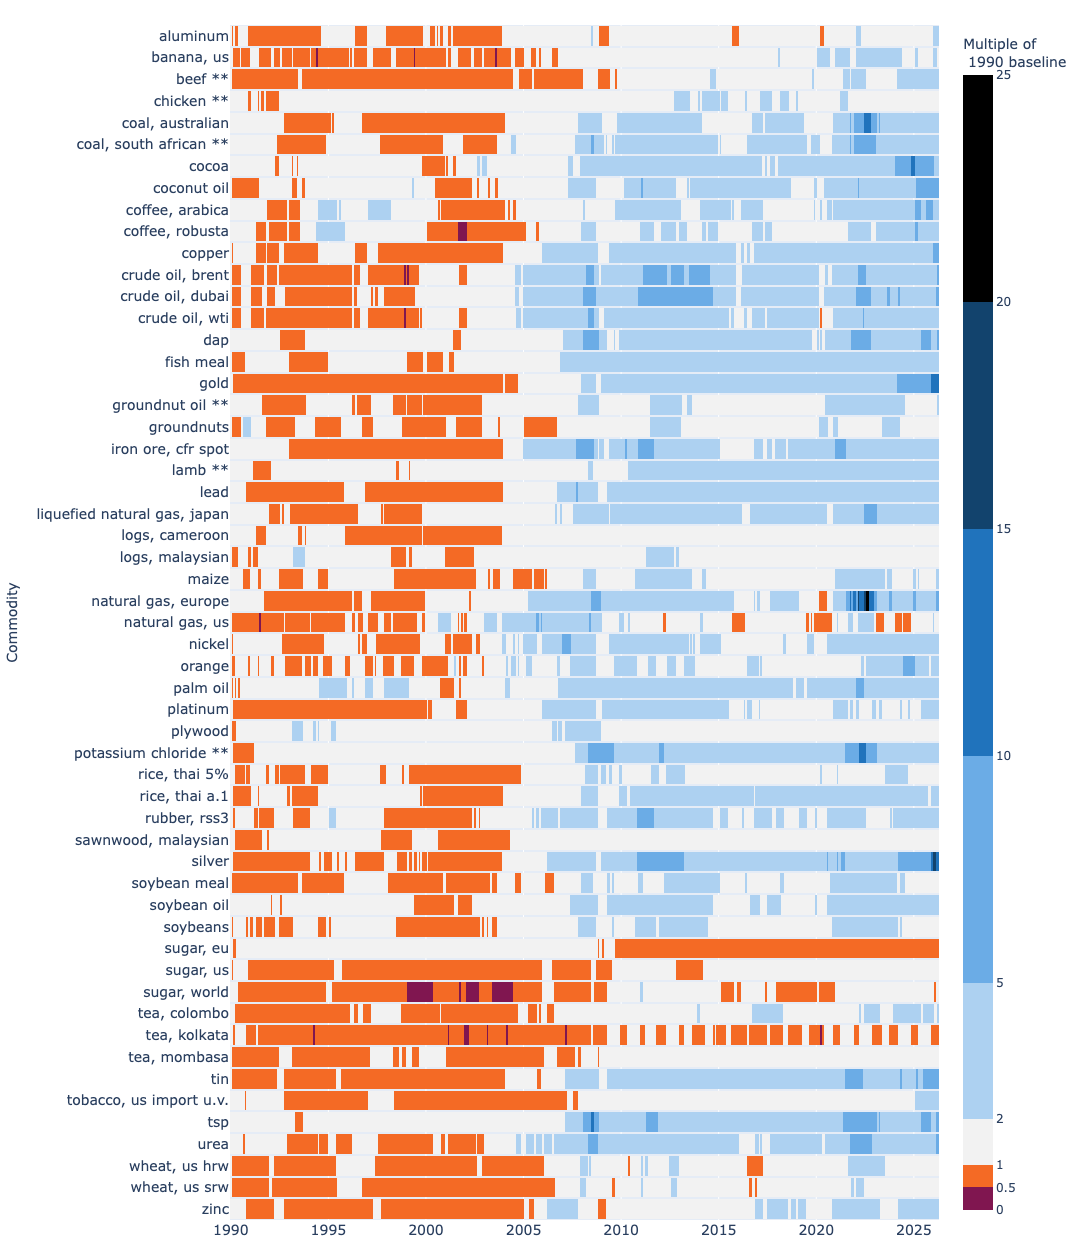

In [295]:
# Visualising commodity price movement as a multiple of 1990 baseline

# colorscale = [
#     (0.00, "#313695")
#     , (1 / max_multiplier, "#313695")
#     , (1 / max_multiplier, "#4575b4")
#     , (2 / max_multiplier, "#4575b4")
#     , (2 / max_multiplier, "#74add1")
#     , (5 / max_multiplier, "#74add1")
#     , (5 / max_multiplier, "#fdae61")
#     , (10 / max_multiplier, "#fdae61")
#     , (10 / max_multiplier, "#f46d43")
#     , (15 / max_multiplier, "#f46d43")
#     , (15 / max_multiplier, "#a50026")
#     , (20 / max_multiplier, "#a50026")
#     , (20 / max_multiplier, "#660119")
#     , (1.00, "#660119")
# ]

colorscale = [
    (-1, "#801650")
    , (-0.5 / max_multiplier, "#801650")
    , (-0.5 / max_multiplier, "#f46d43")
    , (0 / max_multiplier, "#f46d43")
    , (0 / max_multiplier, "#F46A25")
    , (1 / max_multiplier, "#F46A25")
    , (1 / max_multiplier, "#F2F2F2")
    , (2 / max_multiplier, "#F2F2F2")
    , (2 / max_multiplier, "#ADD1F1")
    , (5 / max_multiplier, "#ADD1F1")
    , (5 / max_multiplier, "#6BACE6")
    , (10 / max_multiplier, "#6BACE6")
    , (10 / max_multiplier, "#2073BC")
    , (15 / max_multiplier, "#2073BC")
    , (15 / max_multiplier, "#12436D")
    , (20 / max_multiplier, "#12436D")
    , (20 / max_multiplier, "#000000")
    , (1.00, "#000000")
]

colorscale = [
    (0, "#801650")
    , (0.5 / max_multiplier, "#801650")
    , (0.5 / max_multiplier, "#F46A25")
    , (1 / max_multiplier, "#F46A25")
    , (1 / max_multiplier, "#F2F2F2")
    , (2 / max_multiplier, "#F2F2F2")
    , (2 / max_multiplier, "#ADD1F1")
    , (5 / max_multiplier, "#ADD1F1")
    , (5 / max_multiplier, "#6BACE6")
    , (10 / max_multiplier, "#6BACE6")
    , (10 / max_multiplier, "#2073BC")
    , (15 / max_multiplier, "#2073BC")
    , (15 / max_multiplier, "#12436D")
    , (20 / max_multiplier, "#12436D")
    , (20 / max_multiplier, "#000000")
    , (1.00, "#000000")
]

fig = go.Figure(
    go.Heatmap(
        z = change_df.values
        , x = change_df.columns   
        , y = change_df.index    
        , colorscale = colorscale
        , zmin = 0
        , zmax = max_multiplier
        , ygap = 2 
        , xgap = 0 
        , colorbar = dict(tickvals = [0, 0.5, 1,  2, 5, 10, 15, 20, 25], title = "Multiple of <br> 1990 baseline")))

fig.update_layout(height = 1250
                  , xaxis = dict(side = "bottom", tickfont = dict(size = 14))
                  , yaxis = dict(title = "Commodity", autorange = "reversed", tickfont = dict(size = 14))
                  , margin = dict(t = 25, b = 25))
                  # , title = dict(text = "Change in commodity prices, as a multiplier of a Jan 1990 baseline - Jan 1990 = 1", x = 0.5, font = dict(size = 20)))
fig.show()

In [113]:
# Deriving log-prices and adding them to the dataframe

price = {}
price_cols = []

for commodity in commodities:
    series = pd.Series(np.log(df[commodity]), name = f"{commodity}_price")
    price[f"{commodity}_price"] = series
    price_cols.append(f"{commodity}_price")

prices_df = pd.concat(price.values(), axis = 1)
df = pd.concat([df, prices_df], axis = 1)

In [115]:
# Deriving 1 month commodity log(returns) and adding them to the dataframe

returns = {}
returns_cols = []

for commodity in commodities:
    series = pd.Series(np.log(df[commodity]) - np.log(df[commodity]).shift(periods = 1), name = f"{commodity}_return")
    returns[f"{commodity}_return"] = series
    returns_cols.append(f"{commodity}_return")

returns_df = pd.concat(returns.values(), axis = 1)
df = pd.concat([df, returns_df], axis = 1)

In [117]:
# Feature engineering

In [119]:
# Commodity Trend

commodity_trend = {}
commodity_trend_cols = []

for commodity in df[price_cols]:
    series = pd.Series(
        df[commodity].rolling(window = 6).apply(lambda x: np.polyfit(range(0, len(x)), x, 1)[0], raw = True) , name = f"{commodity}_trend")
    commodity_trend[f"{commodity}_trend"] = series
    commodity_trend_cols.append(f"{commodity}_trend")

commodity_trend_df = pd.concat(commodity_trend.values(), axis = 1)
df = pd.concat([df, commodity_trend_df], axis = 1)

In [120]:
# Commodity Volatility

commodity_volatility = {}
commodity_volatility_cols =[]

for commodity in df[returns_cols]:
    series = pd.Series(df[commodity].rolling(window = 6, min_periods = 1).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw = True), name = f"{commodity}_volatility")
    commodity_volatility[f"{commodity}_volatility"] = series
    commodity_volatility_cols.append(f"{commodity}_volatility")

commodity_volatility_df = pd.concat(commodity_volatility.values(), axis = 1)
df = pd.concat([df, commodity_volatility_df], axis = 1).sort_values(by = "date", ascending = True).reset_index(drop = True)

In [121]:
# Commodity shock

commodity_shock = {}
commodity_shock_cols = []

for commodity in df[returns_cols]:
    series = pd.Series(df[commodity].abs(), name = f"{commodity}_shock")
    commodity_shock[f"{commodity}_shock"] = series
    commodity_shock_cols.append(f"{commodity}_shock")

commodity_shock_df = pd.concat(commodity_shock.values(), axis = 1)
df = pd.concat([df, commodity_shock_df], axis = 1).sort_values(by = "date", ascending = True).reset_index(drop = True)

In [125]:
df = df[df["date"] >= "1990-01-01"].reset_index(drop = True)

In [151]:
# Checking for multicollinearity

data_checks = []

for commodity in commodities:
    results = [
        commodity
        , np.linalg.cond(np.cov(df[[f"{commodity}_price_trend", f"{commodity}_return_volatility", f"{commodity}_return_shock"]].values, rowvar=False))]
    data_checks.append(results)

df_data_checks = pd.DataFrame(data_checks, columns = ["commodity", "feature_set_condition_number"]).sort_values(by = "feature_set_condition_number", ascending = False).reset_index(drop = True)
df_data_checks.head()

,commodity,feature_set_condition_number
0,"tea, kolkata",12.306488
1,plywood,7.891542
2,tsp,7.670742
3,maize,7.640680
4,soybean meal,7.597125


In [87]:
# Selecting a commodity to model

pn.extension()
dropdown = pn.widgets.Select(options = commodities)
dropdown

Select(options=['aluminum', 'banana, ...], value='aluminum')

In [219]:
# Getting relevant commodity columns

commodity = dropdown.value
commodity_cols = [x for x in df if x.startswith(f"{commodity}") and x.endswith(("trend", "volatility", "shock"))]

In [223]:
# Split into training and test datasets
series_length = len(df)
training_rows = int(series_length * 0.8)
train = df[commodity_cols].copy()[:training_rows].to_numpy()
test = df[commodity_cols].copy()[training_rows:].to_numpy()

scaler = StandardScaler()
X_train = scaler.fit_transform(train)
X_test = scaler.transform(test)

In [225]:
# Finding the best models

random_states = np.linspace(0, 9999, 50)
n_components = [2, 3, 4, 5, 6]
covariance_types = ["spherical", "diag", "full", "tied"]

models = []

for r in random_states:
    for n in n_components:
        for c in covariance_types:
            model = GaussianHMM(
                n_components = n
                , covariance_type = c
                , n_iter = 1000
                , random_state = int(r))
                    
            model.fit(X_train)
            models.append([
                commodity
                , int(r)
                , n
                , c
                , model.bic(X_train)
                , model.score(X_train) / len(X_train)
                , model.score(X_test) / len(X_test)
                , ((model.score(X_train) / len(X_train)) - (model.score(X_test) / len(X_test)))
            ])

models_df = pd.DataFrame(models, columns = ["commodity", "random_state", "n_components", "covariance_type", "bic", "train_score", "test_score", "train_test_diff"])
models_df["best_random_state"] = models_df.sort_values(by = "bic", ascending = True).groupby(["n_components", "covariance_type"]).cumcount() + 1

In [226]:
best_random_states = models_df[models_df["best_random_state"] == 1][["random_state", "n_components", "covariance_type"]].copy()

best_models = (
    models_df
    .groupby(["commodity", "n_components", "covariance_type"]).agg(
        min_bic = ("bic", "min")
        , std_bic = ("bic", "std")
        , std_train_test_diff = ("train_test_diff", "std"))
    .sort_values(by = "min_bic")
    .reset_index(drop = False)
    .merge(best_random_states
           , how = "inner"
           , on = ["n_components", "covariance_type"]))

best_models.head(5)

,commodity,n_components,covariance_type,min_bic,std_bic,std_train_test_diff,random_state
0,"crude oil, brent",5,diag,2309.794465,56.060984,0.145720,6325
1,"crude oil, brent",4,diag,2311.176773,45.012069,0.145021,4285
2,"crude oil, brent",5,spherical,2315.739120,47.811388,0.103628,3877
3,"crude oil, brent",6,diag,2323.642956,59.753066,0.146395,4897
4,"crude oil, brent",4,spherical,2326.838768,35.116871,0.085538,9999


In [229]:
# Standardising full dataset

scaler = StandardScaler()
X = scaler.fit_transform(df[commodity_cols].copy().to_numpy())

In [231]:
# Gathering hyperparameters for best models

count_best_models = 3

best_models_dict = {}
    
for model in range(0, count_best_models):
    best_models_dict[model] = {
        "model_no" : model
        , "n_components" : best_models.iloc[model]["n_components"]
        , "covariance_type" : best_models.iloc[model]["covariance_type"]
        , "random_state" : best_models.iloc[model]["random_state"]}

In [233]:
# Testing best models on full dataset

for model_no in range(0, count_best_models):
    model = GaussianHMM(
        n_components = best_models_dict[model_no]["n_components"]
        , covariance_type = best_models_dict[model_no]["covariance_type"]
        , n_iter = 1000
        , random_state = best_models_dict[model_no]["random_state"])

    model.fit(X)
    print(f"{model_no} - {best_models_dict[model_no]["n_components"]}, {best_models_dict[model_no]["covariance_type"]} - BIC: {np.round(model.bic(X), 2)}, LL: {np.round(model.score(X) / len(X), 2)}")
    best_models_dict[model_no]["model"] = model
    best_models_dict[model_no]["states"] = pd.Series(model.predict(X), name = "states")
    best_models_dict[model_no]["transition_probabilities"] = np.round(model.transmat_, 2)
    best_models_dict[model_no]["bic"] = np.round(model.bic(X), 2)
    best_models_dict[model_no]["log-likelihood"] = np.round(model.score(X) / len(X), 2)

0 - 5, diag - BIC: 2676.21, LL: -2.69
1 - 4, diag - BIC: 2789.75, LL: -2.93
2 - 5, spherical - BIC: 2730.12, LL: -2.82


In [235]:
best_models = []

for model, results in best_models_dict.items():
    best_models.append([
        model
        , results["n_components"]
        , results["covariance_type"]
        , results["bic"]
        , results["log-likelihood"]])

best_models_df = pd.DataFrame(best_models, columns = ["model", "n_components", "covariance_type", "bic", "log-likelihood"]).sort_values(by = "bic", ascending = True)
best_models_df.head()

,model,n_components,covariance_type,bic,log-likelihood
0,0,5,diag,2676.21,-2.69
2,2,5,spherical,2730.12,-2.82
1,1,4,diag,2789.75,-2.93


In [237]:
# Analysing feature column mean values for each state

final_models = [0, 1]

for model_no in final_models:
    # print("")
    # print(f"Model No.{model_no}")
    # print("_______________________")
    states = pd.concat([df[commodity_cols]
                        , best_models_dict[model_no]["states"]]
                        , axis = 1)
    state_means = states.groupby("states")[commodity_cols].mean()
    mean_vals = df[commodity_cols].mean(axis = 0).to_frame(name = "mean").T
    max_vals = df[commodity_cols].max(axis = 0).to_frame(name = "max").T
    min_vals = df[commodity_cols].min(axis = 0).to_frame(name = "min").T
    state_means = pd.concat([state_means, mean_vals, max_vals, min_vals], axis = 0)
    state_means = state_means.rename(columns = {f"{commodity}_price_trend" : "trend", f"{commodity}_return_volatility" : "volatility", f"{commodity}_return_shock" : "shock"}) 
    best_models_dict[model_no]["state_means"] = state_means
    # display(state_means)

In [239]:
# Adding state interpretations

state_descriptions = {
    0 : [
        "State 0 - Stable period of growth"
        , "State 1 - Stable period of minor decline"
        , "State 2 - Volatile period of growth"
        , "State 3 - Volatile period of decline"
        , "State 4 - Price shock, High volatility"]
    , 1 : [
        "State 0 - Stable period of growth"
        , "State 1 - Stable period of minor decline"
        , "State 2 - Price shock, High volatility"
        , "State 3 - Volatile period"]
}

for model_no, descriptions in state_descriptions.items():
    print("")
    print(f"Model No.{model_no}")
    print("_______________________")
    state_description = pd.DataFrame(descriptions, columns = ["state_description"])
    best_models_dict[model_no]["state_means"] = pd.concat([best_models_dict[model_no]["state_means"], state_description], axis = 1).fillna("")
    display(best_models_dict[model_no]["state_means"])


Model No.0
_______________________


,trend,volatility,shock,state_description
0,0.029958,0.045420,0.053179,State 0 - Stable period of growth
1,0.046438,0.079647,0.086549,State 1 - Stable period of minor decline
2,-0.035322,0.071757,0.086921,State 2 - Volatile period of growth
3,-0.012389,0.038401,0.036267,State 3 - Volatile period of decline
4,-0.038241,0.140877,0.169727,"State 4 - Price shock, High volatility"
mean,0.003373,0.061768,0.070088,
max,0.188772,0.268175,0.511432,
min,-0.240967,0.015282,0.000322,



Model No.1
_______________________


,trend,volatility,shock,state_description
0,0.010343,0.042369,0.060662,State 0 - Stable period of growth
1,0.008541,0.040396,0.011719,State 1 - Stable period of minor decline
2,-0.024581,0.139715,0.165435,"State 2 - Price shock, High volatility"
3,0.000261,0.074075,0.086577,State 3 - Volatile period
mean,0.003373,0.061768,0.070088,
max,0.188772,0.268175,0.511432,
min,-0.240967,0.015282,0.000322,



Model No.0
State 0 - Stable period of growth
State 1 - Stable period of minor decline
State 2 - Volatile period of growth
State 3 - Volatile period of decline
State 4 - Price shock, High volatility
_______________________


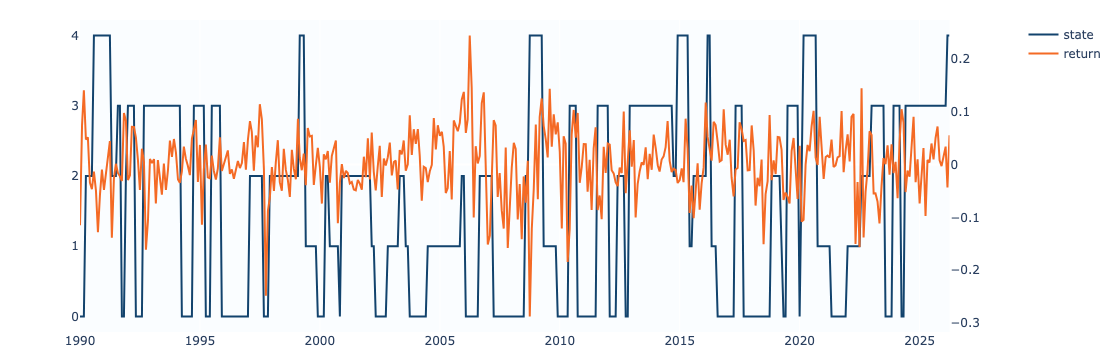


Model No.1
State 0 - Stable period of growth
State 1 - Stable period of minor decline
State 2 - Price shock, High volatility
State 3 - Volatile period
_______________________


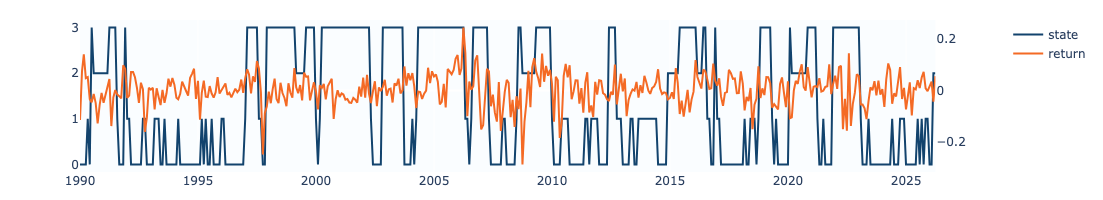

In [291]:
# Visualising states alongside commodity returns

for model_no in final_models:
    print("")
    print(f"Model No.{model_no}")
    [print(x) for x in best_models_dict[model_no]["state_means"]["state_description"] if x != ""]
    print("_______________________")
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(
        go.Scatter(
            x = df["date"]
            , y= best_models_dict[model_no]["states"]
            , mode = "lines"
            , name = "state"
            , line = dict(color = "#12436D"))
        , secondary_y = False)
    fig.update_yaxes(showgrid = False, zeroline = False, tickmode = "linear", dtick = 1, secondary_y = False)
    fig.add_trace(
        go.Scatter(
            x= df["date"]
            , y= df[f"{commodity}_return"]
            , mode = "lines"
            , name = "return"
            , line = dict(color = "#F46A25"))
        , secondary_y = True)
    fig.update_yaxes(showgrid = False, secondary_y = True)
    fig.update_layout(height = 200, margin = dict(t = 20, b = 20), plot_bgcolor = "#FAFDFF")
    fig.show()


Model No.0
State 0 - Stable period of growth
State 1 - Stable period of minor decline
State 2 - Volatile period of growth
State 3 - Volatile period of decline
State 4 - Price shock, High volatility
_______________________


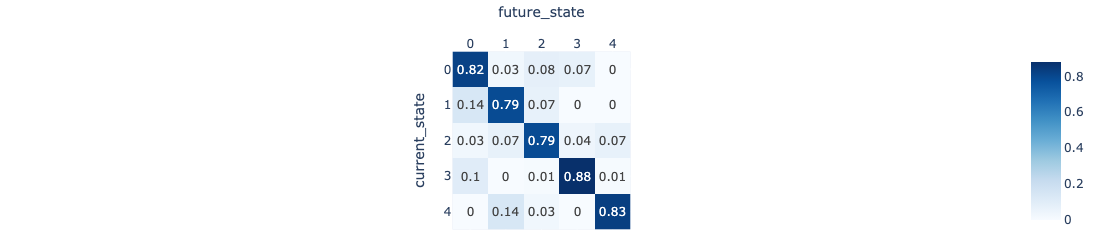


Model No.1
State 0 - Stable period of growth
State 1 - Stable period of minor decline
State 2 - Price shock, High volatility
State 3 - Volatile period
_______________________


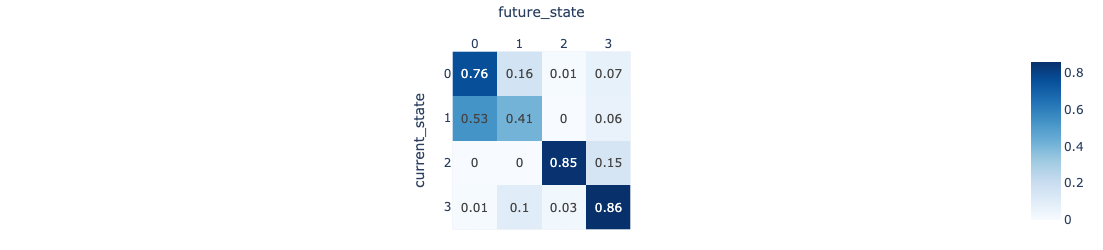

In [271]:
# Visualising state transition matrices

for model_no in final_models:
    print("")
    print(f"Model No.{model_no}")
    [print(x) for x in best_models_dict[model_no]["state_means"]["state_description"] if x != ""]
    print("_______________________")
    fig = px.imshow(best_models_dict[model_no]["transition_probabilities"], text_auto = True, color_continuous_scale = "Blues")
    fig.update_xaxes(side="top", tickmode = "linear", dtick = 1, title = dict(text = "current_state"))
    fig.update_yaxes(tickmode = "linear", dtick = 1, title = dict(text = "test"))
    fig.update_layout(height = 250, margin = dict(t = 20, b = 20))
    fig.show()